# Chatbot with Memory

## Review

[Memory](https://pmc.ncbi.nlm.nih.gov/articles/PMC10410470/) is a cognitive function that allows people to store, retrieve, and use information to understand their present and future. 

There are [various long-term memory types](https://docs.langchain.com/oss/python/concepts/memory#memory-types) that can be used in AI applications.

## Goals

Here, we'll introduce the [LangGraph Memory Store](https://reference.langchain.com/python/langgraph/store/?h=basestor#langgraph.store.base.BaseStore) as a way to save and retrieve long-term memories.

We'll build a chatbot that uses both `short-term (within-thread)` and `long-term (across-thread)` memory.
 
We'll focus on long-term [semantic memory](https://docs.langchain.com/oss/python/concepts/memory#semantic-memory), which will be facts about the user. 

These long-term memories will be used to create a personalized chatbot that can remember facts about the user.

It will save memory ["in the hot path"](https://docs.langchain.com/oss/python/concepts/memory#writing-memories), as the user is chatting with it.

## Introduction to the LangGraph Store

The  [LangGraph Memory Store](https://reference.langchain.com/python/langgraph/store/?h=basestor#langgraph.store.base.BaseStore) provides a way to store and retrieve information *across threads* in LangGraph.

This is an  [open source base class](https://blog.langchain.com/launching-long-term-memory-support-in-langgraph/) for persistent `key-value` stores.

In [1]:
import uuid
from langgraph.store.memory import InMemoryStore
in_memory_store = InMemoryStore()

When storing objects (e.g., memories) in the [Store](https://reference.langchain.com/python/langgraph/store/?h=basestor#langgraph.store.base.BaseStore), we provide:

- The `namespace` for the object, a tuple (similar to directories)
- the object `key` (similar to filenames)
- the object `value` (similar to file contents)

We use the [put](https://reference.langchain.com/python/langgraph/store/?h=basestor#langgraph.store.base.BaseStore.put) method to save an object to the store by `namespace` and `key`.

![langgraph_store.png](attachment:6281b4e3-4930-467e-83ce-ba1aa837ca16.png)

In [2]:
# Namespace for the memory to save
user_id = "1"
namespace_for_memory = (user_id, "memories")

# Save a memory to namespace as key and value
key = str(uuid.uuid4())

# The value needs to be a dictionary  
value = {"food_preference" : "I like pizza"}

# Save the memory
in_memory_store.put(namespace_for_memory, key, value)

We use [search](https://reference.langchain.com/python/langgraph/store/?h=basestor#langgraph.store.base.BaseStore.search) to retrieve objects from the store by `namespace`.

This returns a list.

In [3]:
# Search 
memories = in_memory_store.search(namespace_for_memory)
type(memories)

list

In [4]:
# The key, value
print(memories[0].key, memories[0].value)

735f2ba9-f603-44a8-9ac1-75f0857c5dba {'food_preference': 'I like pizza'}


We can also use [get](https://reference.langchain.com/python/langgraph/store/?h=basestor#langgraph.store.base.BaseStore.get) to retrieve an object by `namespace` and `key`.

In [5]:
# Get the memory by namespace and key
memory = in_memory_store.get(namespace_for_memory, key)
memory.dict()

{'namespace': ['1', 'memories'],
 'key': '735f2ba9-f603-44a8-9ac1-75f0857c5dba',
 'value': {'food_preference': 'I like pizza'},
 'created_at': '2026-09-15T18:57:55.380822+00:00',
 'updated_at': '2026-09-15T18:57:55.380824+00:00'}

## Chatbot with long-term memory

We want a chatbot that [has two types of memory](https://docs.google.com/presentation/d/181mvjlgsnxudQI6S3ritg9sooNyu4AcLLFH1UK0kIuk/edit#slide=id.g30eb3c8cf10_0_156):

1. `Short-term (within-thread) memory`: Chatbot can persist conversational history and / or allow interruptions in a chat session.
2. `Long-term (cross-thread) memory`: Chatbot can remember information about a specific user *across all chat sessions*.

For `short-term memory`, we'll use a [checkpointer](https://docs.langchain.com/oss/python/langgraph/persistence#checkpointer-libraries). 

See Module 2 and our [conceptual docs](https://docs.langchain.com/oss/python/langgraph/persistence) for more on checkpointers, but in summary:

* They write the graph state at each step to a thread.
* They persist the chat history in the thread.
* They allow the graph to be interrupted and / or resumed from any step in the thread.
 
And, for `long-term memory`, we'll use the [LangGraph Store](https://reference.langchain.com/python/langgraph/store/?h=basestor#langgraph.store.base.BaseStore) as introduced above.

In [6]:
from langchain.chat_models import init_chat_model

llm = init_chat_model(
    model="models/gemini-3.5-flash-lite", 
    model_provider="google_genai",
    max_retries = 5
)

The chat history will be saved to short-term memory using the checkpointer.

The chatbot will reflect on the chat history. 

It will then create and save a memory to the [LangGraph Store](https://reference.langchain.com/python/langgraph/store/?h=basestor#langgraph.store.base.BaseStore).

This memory is accessible in future chat sessions to personalize the chatbot's responses.

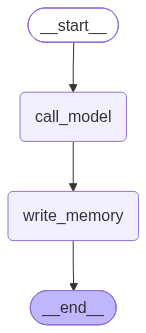

In [15]:
from IPython.display import Image, display

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.store.base import BaseStore

from langchain_core.messages import HumanMessage, SystemMessage, get_buffer_string
from langchain_core.runnables.config import RunnableConfig

# Chatbot instruction
MODEL_SYSTEM_MESSAGE = """You are a helpful assistant with memory that provides information about the user. 
If you have memory for this user, use it to personalize your responses.
Here is the memory (it may be empty): {memory}"""

# Create new memory from the chat history and any existing memory
CREATE_MEMORY_INSTRUCTION = """"You are collecting information about the user to personalize your responses.

CURRENT USER INFORMATION:
{memory}

INSTRUCTIONS:
1. Review the chat history below carefully
2. Identify new information about the user, such as:
   - Personal details (name, location)
   - Preferences (likes, dislikes)
   - Interests and hobbies
   - Past experiences
   - Goals or future plans
3. Merge any new information with existing memory
4. Format the memory as a clear, bulleted list
5. If new information conflicts with existing memory, keep the most recent version

Remember: Only include factual information directly stated by the user. Do not make assumptions or inferences.

Based on the chat history below, please update the user information:"""

def call_model(state: MessagesState, config: RunnableConfig, store: BaseStore):

    """Load memory from the store and use it to personalize the chatbot's response."""
    
    # Get the user ID from the config
    user_id = config["configurable"]["user_id"]

    # Retrieve memory from the store
    namespace = ("memory", user_id)
    key = "user_memory"
    existing_memory = store.get(namespace, key)

    # Extract the actual memory content if it exists and add a prefix
    if existing_memory:
        # Value is a dictionary with a memory key
        existing_memory_content = existing_memory.value.get('memory')
    else:
        existing_memory_content = "No existing memory found."

    # Format the memory in the system prompt
    system_msg = MODEL_SYSTEM_MESSAGE.format(memory=existing_memory_content)
    
    # Respond using memory as well as the chat history
    response = llm.invoke([SystemMessage(content=system_msg)]+state["messages"])

    return {"messages": response}

def write_memory(state: MessagesState, config: RunnableConfig, store: BaseStore):
    """Reflect on the chat history and save a memory to the store."""
    
    # 1. Get the user ID from the config
    user_id = config["configurable"]["user_id"]

    # 2. Retrieve existing memory from the store
    namespace = ("memory", user_id)
    existing_memory = store.get(namespace, "user_memory")
        
    # 3. Extract existing memory text
    if existing_memory:
        existing_memory_content = existing_memory.value.get('memory', "No existing memory found.")
    else:
        existing_memory_content = "No existing memory found."

    # 4. Convert the full chat history to a formatted text string
    conversation_history = get_buffer_string(state['messages'])

    # 5. Format system instructions
    system_msg = CREATE_MEMORY_INSTRUCTION.format(memory=existing_memory_content)
    
    # 6. Gemini No-Prefill Fix: Send the conversation history inside a HumanMessage
    user_prompt = f"Here is the conversation history:\n\n{conversation_history}\n\nPlease extract and update the user memory based on the instructions."
    
    new_memory = llm.invoke([
        SystemMessage(content=system_msg),
        HumanMessage(content=user_prompt)
    ])

    # 7. Gemini List Content Fix: Ensure clean string storage
    content = new_memory.content
    if isinstance(content, list):
        content = content[0].get("text", "") if content else ""

    # 8. Overwrite the existing memory in the store
    key = "user_memory"
    store.put(namespace, key, {"memory": content})

# Define the graph
builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_node("write_memory", write_memory)
builder.add_edge(START, "call_model")
builder.add_edge("call_model", "write_memory")
builder.add_edge("write_memory", END)

# Store for long-term (across-thread) memory
across_thread_memory = InMemoryStore()

# Checkpointer for short-term (within-thread) memory
within_thread_memory = MemorySaver()

# Compile the graph with the checkpointer fir and store
graph = builder.compile(checkpointer=within_thread_memory, store=across_thread_memory)

# View
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

When we interact with the chatbot, we supply two things:

1. `Short-term (within-thread) memory`: A `thread ID` for persisting the chat history.
2. `Long-term (cross-thread) memory`: A `user ID` to namespace long-term memories to the user.

Let's see how these work together in practice. 

In [16]:
# We supply a thread ID for short-term (within-thread) memory
# We supply a user ID for long-term (across-thread) memory 
config = {"configurable": {"thread_id": "1", "user_id": "1"}}

# User input 
input_messages = [HumanMessage(content="Hi, my name is Mark")]

# Run the graph
for chunk in graph.stream({"messages": input_messages}, config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

Hi, my name is Mark
================================== Ai Message ==================================

[{'type': 'text', 'text': 'Hi Mark! Nice to meet you. How can I help you today?', 'extras': {'signature': 'El4KXAERTTIPSlGXBtZcECtsnSCWZCH7jfmzKxnrPdV3lHfuT0ROCfxQSqukRCASGIM5O+DBQeh8/Tgxi/5A1RNeUgjSUznnSViryu89y7nWXRyzxky2ftKVg25jUZNC'}}]


In [17]:
# User input 
input_messages = [HumanMessage(content="I like to bike around San Francisco")]

# Run the graph
for chunk in graph.stream({"messages": input_messages}, config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

I like to bike around San Francisco
================================== Ai Message ==================================

[{'type': 'text', 'text': "That's awesome, Mark! Biking around San Francisco is a fantastic way to see the city, though those hills definitely give you a workout. \n\nDo you have a favorite route you like to take—maybe cruising along the Embarcadero, heading through Golden Gate Park to Ocean Beach, or tackling the steep climbs in the neighborhoods?", 'extras': {'signature': 'El4KXAERTTIP0x3Y/74O/silArG4/DH6E65mhgnoAE/0ei7uOm3ZJ9VeXMWMyeW++wf/3g9tF2lFmkZZ2WYWoMRbHexkd0SxLHNEZItWC6OQFzZQPtq4NQdvGjV3+M3t'}}]


We're using the `MemorySaver` checkpointer for within-thread memory.

This saves the chat history to the thread.

We can look at the chat history saved to the thread.

In [18]:
thread = {"configurable": {"thread_id": "1"}}
state = graph.get_state(thread).values
for m in state["messages"]: 
    m.pretty_print()

================================ Human Message =================================

Hi, my name is Mark
================================== Ai Message ==================================

[{'type': 'text', 'text': 'Hi Mark! Nice to meet you. How can I help you today?', 'extras': {'signature': 'El4KXAERTTIPSlGXBtZcECtsnSCWZCH7jfmzKxnrPdV3lHfuT0ROCfxQSqukRCASGIM5O+DBQeh8/Tgxi/5A1RNeUgjSUznnSViryu89y7nWXRyzxky2ftKVg25jUZNC'}}]
================================ Human Message =================================

I like to bike around San Francisco
================================== Ai Message ==================================

[{'type': 'text', 'text': "That's awesome, Mark! Biking around San Francisco is a fantastic way to see the city, though those hills definitely give you a workout. \n\nDo you have a favorite route you like to take—maybe cruising along the Embarcadero, heading through Golden Gate Park to Ocean Beach, or tackling the steep climbs in the neighborhoods?", 'extras': {'signature':

Recall that we compiled the graph with our the store: 

```python
across_thread_memory = InMemoryStore()
```

And, we added a node to the graph (`write_memory`) that reflects on the chat history and saves a memory to the store.

We can to see if the memory was saved to the store.

In [19]:
# Namespace for the memory to save
user_id = "1"
namespace = ("memory", user_id)
existing_memory = across_thread_memory.get(namespace, "user_memory")
existing_memory.dict()

{'namespace': ['memory', '1'],
 'key': 'user_memory',
 'value': {'memory': '- Name: Mark\n- Location: San Francisco\n- Interests and hobbies: Biking'},
 'created_at': '2026-09-15T19:04:30.585625+00:00',
 'updated_at': '2026-09-15T19:04:30.585632+00:00'}

Now, let's kick off a *new thread* with the *same user ID*.

We should see that the chatbot remembered the user's profile and used it to personalize the response.

In [20]:
# We supply a user ID for across-thread memory as well as a new thread ID
config = {"configurable": {"thread_id": "2", "user_id": "1"}}

# User input 
input_messages = [HumanMessage(content="Hi! Where would you recommend that I go biking?")]

# Run the graph
for chunk in graph.stream({"messages": input_messages}, config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

Hi! Where would you recommend that I go biking?
================================== Ai Message ==================================

[{'type': 'text', 'text': "Hey Mark! Since you’re in San Francisco, you have access to some of the most iconic and diverse biking routes anywhere. \n\nHere are a few recommendations depending on the kind of ride you're looking for:\n\n1. **The Classic Coastal Cruise (Golden Gate Bridge to Sausalito):** \n   Head across the Golden Gate Bridge and cruise down into Sausalito. It’s touristy for a reason—the views of the bay and the city skyline are unbeatable. *Pro tip:* Take the ferry back to San Francisco so you don't have to climb the Marin Headlands on the return (unless you want the workout!).\n\n2. **The Urban Green Oasis (Golden Gate Park to Ocean Beach):** \n   Ride through the Panhandle and all the way through Golden Gate Park on JFK Drive (which is car-free) out to the Gr

In [21]:
# User input 
input_messages = [HumanMessage(content="Great, are there any bakeries nearby that I can check out? I like a croissant after biking.")]

# Run the graph
for chunk in graph.stream({"messages": input_messages}, config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

Great, are there any bakeries nearby that I can check out? I like a croissant after biking.
================================== Ai Message ==================================

[{'type': 'text', 'text': "Nothing beats a good croissant after a ride, Mark! Since I don't know *exactly* which neighborhood you're starting in or heading toward today, here are some phenomenal bakeries strategically located near the biking routes we just talked about:\n\n### Near the Embarcadero / Marina / Waterfront:\n*   **B. Patisserie (Pacific Heights / near Marina):** If you are willing to make a very short climb up from the waterfront, you *have* to go here. Their kouign-amann is legendary, and their regular and chocolate croissants are flaky, buttery perfection. \n*   **Arsicault Bakery (Inner Richmond / Golden Gate Park area):** Widely considered to have some of the best croissants in the entire country (Bon Appétit even nam